# Swiggy revenue analysis



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')
sns.set()
from datetime import datetime

In [ ]:
df = pd.read_excel('swiggy_data.xlsx')

In [ ]:
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


In [ ]:
df.tail(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197420,Sikkim,Gangtok,2025-02-09,Mama's Kitchen,Gangtok,Momos,Mushroom cheese steam momo ...,112.0,4.4,0
197421,Sikkim,Gangtok,2025-07-28,Mama's Kitchen,Gangtok,Momos,Mushroom cheese fried momo ...,126.0,4.4,0
197422,Sikkim,Gangtok,2025-03-17,Mama's Kitchen,Gangtok,Momos,Mushroom cheese chilli momo ...,140.0,4.4,0
197423,Sikkim,Gangtok,2025-06-18,Mama's Kitchen,Gangtok,Momos,Soya cheese steam momo ...,84.0,4.4,0
197424,Sikkim,Gangtok,2025-08-11,Mama's Kitchen,Gangtok,Momos,Soya cheese fried momo ...,98.0,4.4,0
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [ ]:
df.shape[1]

10

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [ ]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [ ]:
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


# Data cleaning for KPI


In [ ]:
# Standardize column names (example – change according to your file)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [ ]:
# Create helper columns
df['month'] = df['order_date'].dt.to_period('M').astype(str)
df['quarter'] = df['order_date'].dt.to_period('Q').astype(str)
df['day_of_week'] = df['order_date'].dt.day_name()
df['week'] = df['order_date'].dt.isocalendar().week

In [ ]:
# Handle missing ratings / sales
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['sales'] = pd.to_numeric(df['price_(inr)'], errors='coerce')   # Correctly use 'price_(inr)' for sales

In [ ]:
df.dropna(subset=['rating', 'sales'], inplace=True)

In [ ]:
# Drop rows with no date or sales
df = df.dropna(subset=['order_date', 'sales'])

# Calculate 5 KPI

In [ ]:
total_sales = df['sales'].sum()
avg_rating = df['rating'].mean()
total_orders = df['order_date'].nunique()          # or len(df)
avg_order_value = total_sales / total_orders
ratings_count = df['rating'].notna().sum()

print(f"Total Sales ($): {total_sales:,.0f}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Average Order Value (₹): {avg_order_value:,.0f}")
print(f"Ratings Count: {ratings_count}")
print(f"Total Orders: {total_orders}")

Total Sales ($): 5,392,753,715,899,400,192
Average Rating: 4.34
Average Order Value (₹): 22,192,402,123,042,800
Ratings Count: 197430
Total Orders: 243


# Monthly Sales Trend

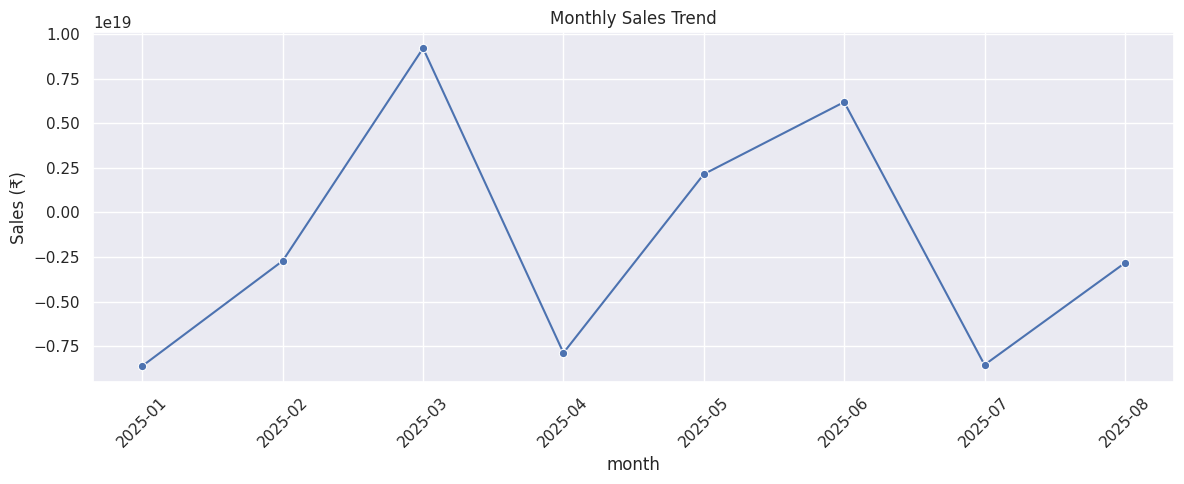

In [ ]:
monthly = df.groupby('month')['sales'].sum().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='month', y='sales', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.ylabel('Sales (₹)')
plt.tight_layout()
plt.show()

# Daily sales trend [End of week]

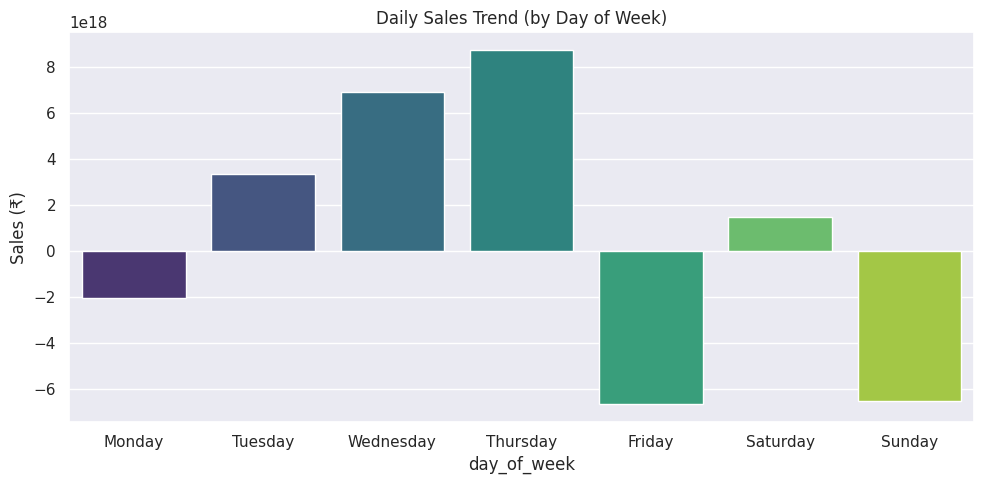

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['sales'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=daily, x='day_of_week', y='sales', palette='viridis')
plt.title('Daily Sales Trend (by Day of Week)')
plt.ylabel('Sales (₹)')
plt.tight_layout()
plt.show()

# Total Sales by Food Type (Veg vs Non-Veg)

In [ ]:
def get_food_type(dish_name):
    dish_name_lower = str(dish_name).lower()
    # Keywords often found in non-vegetarian dishes
    non_veg_keywords = ['chicken', 'mutton', 'fish', 'prawn', 'egg', 'meat']

    for keyword in non_veg_keywords:
        if keyword in dish_name_lower:
            return 'Non-Veg'

    # If no explicit non-veg keyword is found, classify as Veg
    # This is a simplification and might misclassify some items if dish names are ambiguous
    return 'Veg'

df['food_type'] = df['dish_name'].apply(get_food_type)

sales_by_food_type = df.groupby('food_type')['price_(inr)'].sum().reset_index()

fig = px.bar(
    sales_by_food_type,
    x='food_type',
    y='price_(inr)',
    title='Total Sales by Food Type (Veg vs Non-Veg)',
    color='food_type',
    labels={'price_(inr)': 'Total Sales (INR)', 'food_type': 'Food Type'},
    color_discrete_map={'Veg': 'green', 'Non-Veg': 'red'}
)
fig.update_layout(xaxis_title='Food Type', yaxis_title='Total Sales (INR)')
fig.show()

# Total Sales by State map

In [ ]:
state_sales = df.groupby('state')['price_(inr)'].sum().reset_index()

fig = px.choropleth(
    state_sales,
    locations='state',
    locationmode='country names', # Assuming state names are recognized by plotly
    color='price_(inr)', # Use the correct column name for coloring
    hover_name='state',
    color_continuous_scale='Blues',
    title='Total Sales by State',
    scope='asia' # Focusing the map on Asia to help with India's states
)
fig.show()

# Quarterly Performance Summary

In [ ]:
quarterly_sales = df.groupby('quarter')['sales'].sum().reset_index()

fig = px.bar(
    quarterly_sales,
    x='quarter',
    y='sales',
    title='Quarterly Sales Performance',
    labels={'sales': 'Total Sales (INR)', 'quarter': 'Quarter'},
    color='quarter'
)
fig.update_layout(xaxis_title='Quarter', yaxis_title='Total Sales (INR)')
fig.show()

# Top 5 Cities by Sales

In [ ]:
top_5_cities = df.groupby('city')['sales'].sum().nlargest(5).reset_index()

print("Top 5 Cities by Sales:")
print(top_5_cities)

Top 5 Cities by Sales:
        city       sales
0  Bengaluru  5456798.41
1    Lucknow  3117359.65
2  Hyderabad  3021711.62
3     Mumbai  3015573.35
4  New Delhi  2829180.60


In [ ]:
fig = px.bar(
    top_5_cities,
    x='city',
    y='sales',
    title='Top 5 Cities by Sales',
    labels={'city': 'City', 'sales': 'Total Sales (INR)'},
    color='city'
)
fig.update_layout(xaxis_title='City', yaxis_title='Total Sales (INR)')
fig.show()

# Weekly Trend Analysis

In [ ]:
weekly_sales = df.groupby('week')['sales'].sum().reset_index()
weekly_sales = weekly_sales.sort_values(by='week') # Ensure chronological order

fig = px.line(
    weekly_sales,
    x='week',
    y='sales',
    title='Weekly Sales Trend',
    labels={'week': 'Week Number', 'sales': 'Total Sales (INR)'},
    markers=True
)
fig.update_layout(xaxis_title='Week Number', yaxis_title='Total Sales (INR)')
fig.show()

# Bonus – Put Everything in One Dashboard Style Cell

--- Key Performance Indicators ---
Total Sales (₹): 53,012,506
Average Rating: 4.34
Average Order Value (₹): 218,158
Ratings Count: 197430
Total Orders: 243




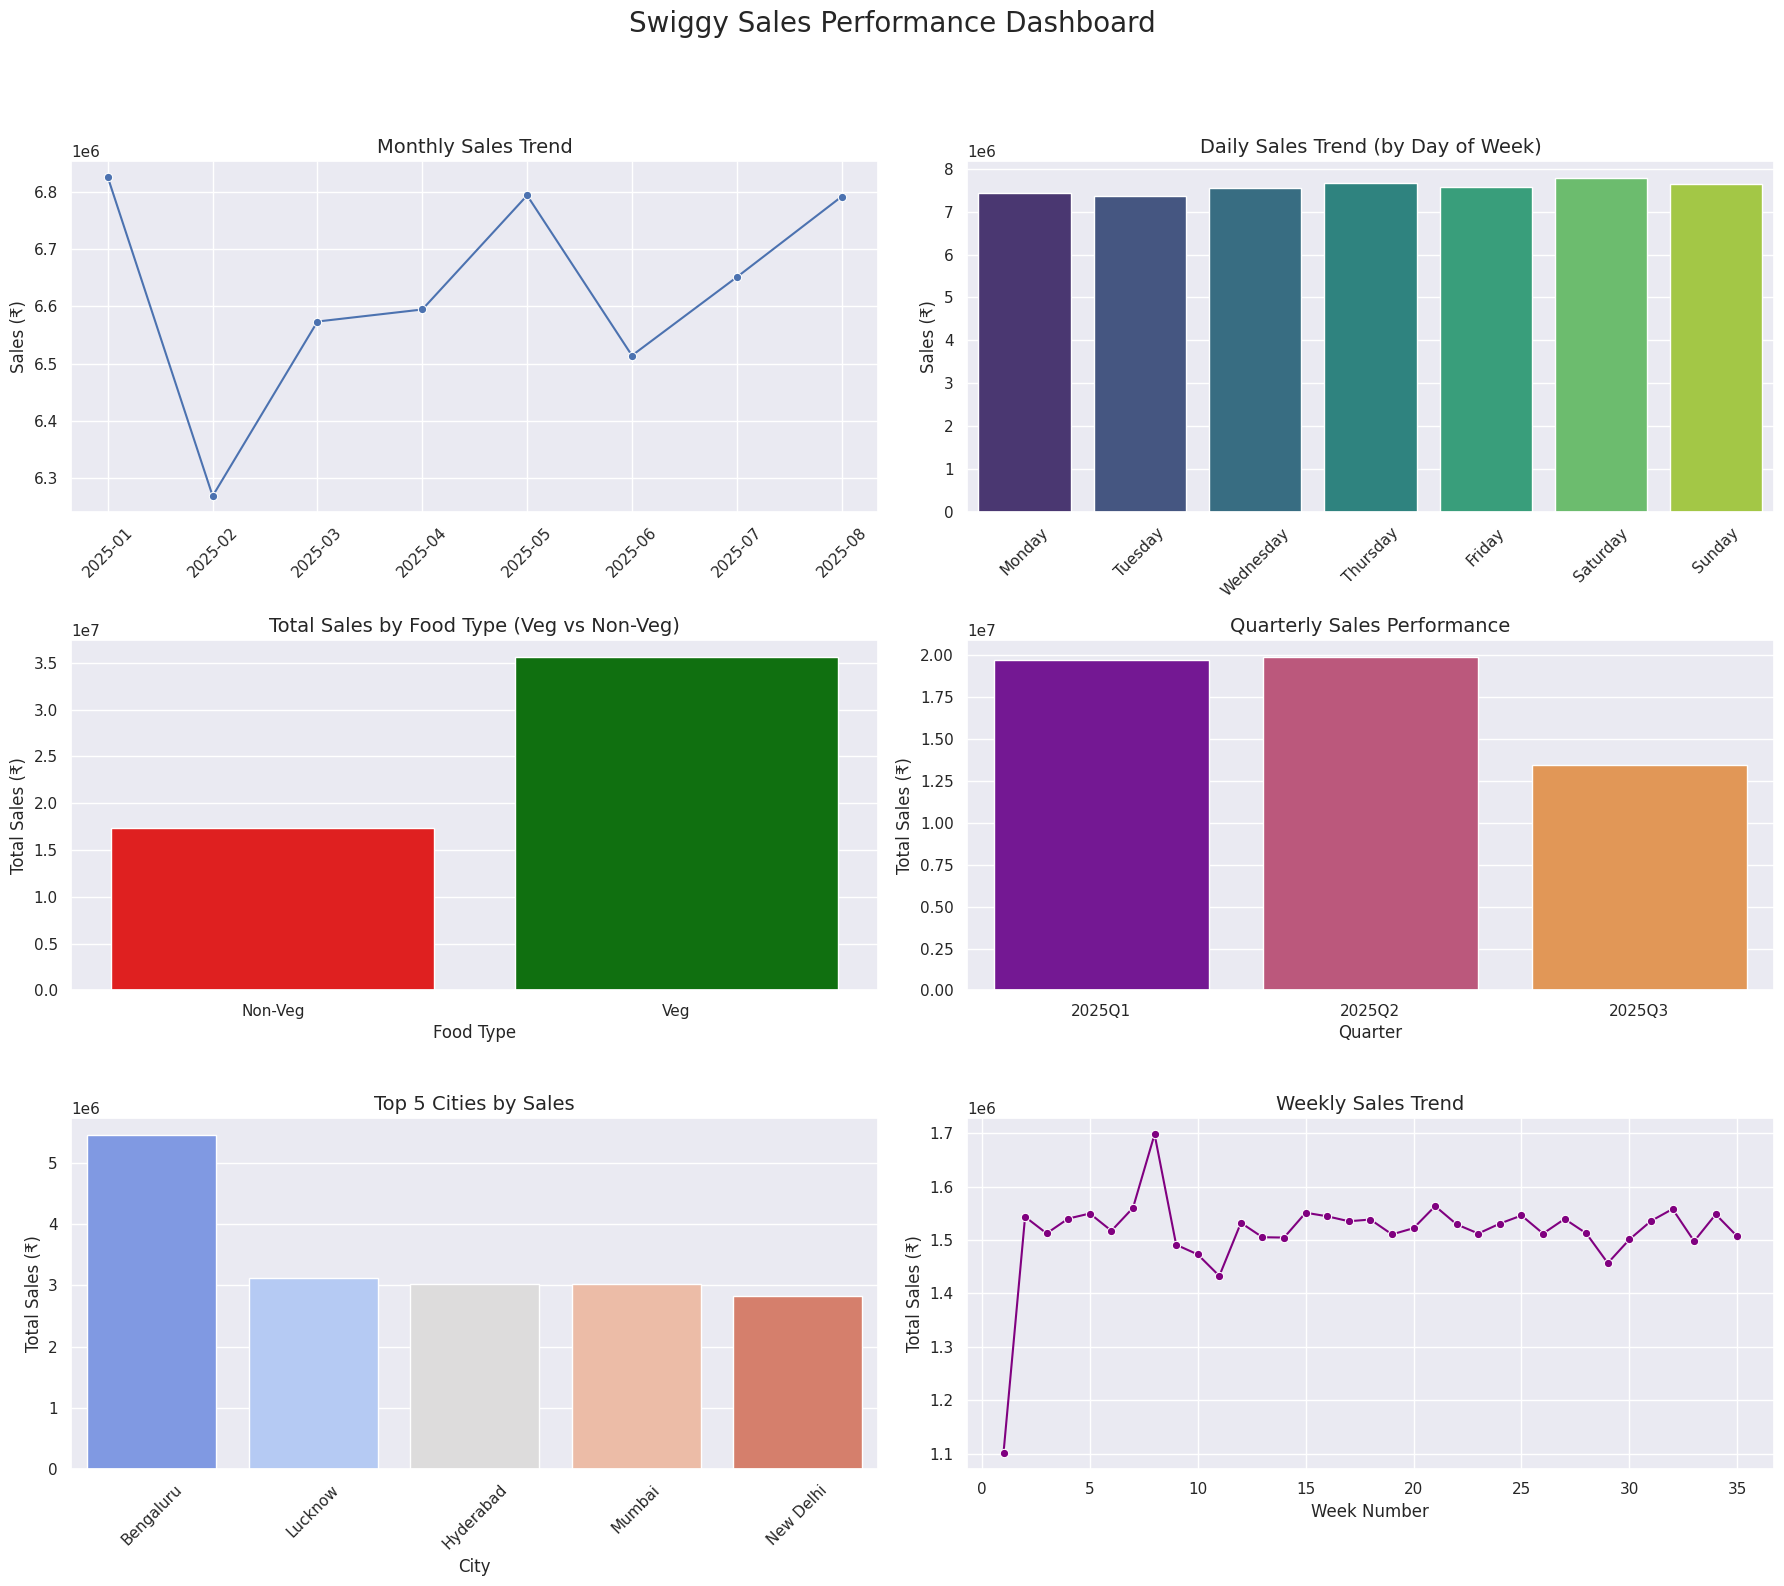

In [ ]:
print('--- Key Performance Indicators ---')
total_sales = df['sales'].sum()
avg_rating = df['rating'].mean()
total_orders = df['order_date'].nunique()
avg_order_value = total_sales / total_orders
ratings_count = df['rating'].notna().sum()

print(f"Total Sales (₹): {total_sales:,.0f}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Average Order Value (₹): {avg_order_value:,.0f}")
print(f"Ratings Count: {ratings_count}")
print(f"Total Orders: {total_orders}")
print('\n' + '='*40 + '\n')


plt.figure(figsize=(18, 16))
plt.suptitle('Swiggy Sales Performance Dashboard', fontsize=20, y=1.02)

# 1. Monthly Sales Trend
plt.subplot(3, 2, 1)
monthly = df.groupby('month')['sales'].sum().reset_index()
sns.lineplot(data=monthly, x='month', y='sales', marker='o')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Sales (₹)')
plt.xlabel('')

# 2. Daily Sales Trend (by Day of Week)
plt.subplot(3, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('day_of_week')['sales'].sum().reindex(day_order).reset_index()
sns.barplot(data=daily, x='day_of_week', y='sales', palette='viridis')
plt.title('Daily Sales Trend (by Day of Week)', fontsize=14)
plt.ylabel('Sales (₹)')
plt.xlabel('')
plt.xticks(rotation=45)

# 3. Total Sales by Food Type (Veg vs Non-Veg)
plt.subplot(3, 2, 3)
sales_by_food_type = df.groupby('food_type')['sales'].sum().reset_index()
sns.barplot(data=sales_by_food_type, x='food_type', y='sales', palette={'Veg': 'green', 'Non-Veg': 'red'})
plt.title('Total Sales by Food Type (Veg vs Non-Veg)', fontsize=14)
plt.ylabel('Total Sales (₹)')
plt.xlabel('Food Type')

# 4. Quarterly Sales Performance
plt.subplot(3, 2, 4)
quarterly_sales = df.groupby('quarter')['sales'].sum().reset_index()
sns.barplot(data=quarterly_sales, x='quarter', y='sales', palette='plasma')
plt.title('Quarterly Sales Performance', fontsize=14)
plt.ylabel('Total Sales (₹)')
plt.xlabel('Quarter')

# 5. Top 5 Cities by Sales
plt.subplot(3, 2, 5)
top_5_cities = df.groupby('city')['sales'].sum().nlargest(5).reset_index()
sns.barplot(data=top_5_cities, x='city', y='sales', palette='coolwarm')
plt.title('Top 5 Cities by Sales', fontsize=14)
plt.ylabel('Total Sales (₹)')
plt.xlabel('City')
plt.xticks(rotation=45)

# 6. Weekly Sales Trend
plt.subplot(3, 2, 6)
weekly_sales = df.groupby('week')['sales'].sum().reset_index()
weekly_sales = weekly_sales.sort_values(by='week')
sns.lineplot(data=weekly_sales, x='week', y='sales', marker='o', color='purple')
plt.title('Weekly Sales Trend', fontsize=14)
plt.ylabel('Total Sales (₹)')
plt.xlabel('Week Number')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()


# Export Results

In [ ]:
print('Exporting results...')

# Export processed DataFrame to CSV
df.to_csv('swiggy_processed_data.csv', index=False)
print('Processed data exported to swiggy_processed_data.csv')

# Save the last generated figure (dashboard) to a PNG file
# Ensure the dashboard cell was run directly before this export to have the figure active
plt.savefig('swiggy_sales_dashboard.png', bbox_inches='tight')
print('Dashboard plot exported to swiggy_sales_dashboard.png')

print('Export complete.')

Exporting results...
Processed data exported to swiggy_processed_data.csv
Dashboard plot exported to swiggy_sales_dashboard.png
Export complete.


<Figure size 640x480 with 0 Axes>

## Top 5 Restaurants by Sales Volume

In [ ]:
top_5_restaurants = df.groupby('restaurant_name')['sales'].sum().nlargest(5).reset_index()

print("Top 5 Restaurants by Sales Volume:")
display(top_5_restaurants)

Top 5 Restaurants by Sales Volume:


,restaurant_name,sales
0,KFC,4246951.70
1,McDonald's,3343094.58
2,Pizza Hut,2133265.69
3,Burger King,1900817.09
4,Domino's Pizza,1834022.32


## README.md for Swiggy Revenue Analysis

# Swiggy Revenue Analysis

This project performs an in-depth exploratory data analysis (EDA) and revenue analysis on a dataset of Swiggy food orders. The goal is to uncover key performance indicators (KPIs), identify sales trends, understand customer behavior, and pinpoint top-performing entities (cities, restaurants, food types).

## Table of Contents

1.  [Introduction](#introduction)
2.  [Dataset](#dataset)
3.  [Goals of the Analysis](#goals-of-the-analysis)
4.  [Methodology](#methodology)
5.  [Key Findings and Insights](#key-findings-and-insights)
6.  [Dashboard Summary](#dashboard-summary)
7.  [How to Run the Code](#how-to-run-the-code)
8.  [Dependencies](#dependencies)
9.  [File Structure](#file-structure)
10. [Conclusion](#conclusion)

## Introduction

Swiggy is a prominent online food ordering and delivery platform. Understanding sales patterns, customer preferences, and operational efficiency is crucial for business growth. This analysis leverages a sample Swiggy sales dataset to provide actionable insights into revenue generation, customer satisfaction, and market dynamics.

## Dataset

The analysis is based on the `swiggy_data.xlsx` file, which contains detailed information about individual orders, including:
-   `State`, `City`, `Location`
-   `Order Date`
-   `Restaurant Name`
-   `Category`, `Dish Name`
-   `Price (INR)`
-   `Rating`, `Rating Count`

## Goals of the Analysis

-   Calculate key business metrics (KPIs) such as total sales, average order value, and average rating.
-   Identify monthly, daily, quarterly, and weekly sales trends.
-   Analyze sales distribution across different food types (Veg vs. Non-Veg).
-   Determine top-performing cities and restaurants by sales volume.
-   Visualize insights through various charts and a consolidated dashboard.

## Methodology

The analysis follows a structured approach:

1.  **Data Loading**: The `swiggy_data.xlsx` file is loaded into a Pandas DataFrame.
2.  **Initial Data Exploration**: Examination of data types, missing values, and summary statistics (`df.head()`, `df.info()`, `df.describe()`).
3.  **Data Cleaning and Preparation**:
    -   Standardizing column names (e.g., `Price (INR)` to `price_inr`).
    -   Converting `Order Date` to datetime objects.
    -   Creating helper columns: `month`, `quarter`, `day_of_week`, `week`.
    -   Handling missing `Rating` and `Price` values by converting them to numeric and dropping rows with `NaN` values.
    -   Creating a `sales` column from `price_(inr)`.
    -   Classifying dishes as 'Veg' or 'Non-Veg' based on keywords in `Dish Name`.
4.  **KPI Calculation**:
    -   `Total Sales`
    -   `Average Rating`
    -   `Total Orders`
    -   `Average Order Value`
    -   `Ratings Count`
5.  **Exploratory Data Analysis (EDA) and Visualization**:
    -   **Monthly Sales Trend**: Line plot showing total sales per month.
    -   **Daily Sales Trend**: Bar plot showing total sales by day of the week.
    -   **Total Sales by Food Type**: Bar plot comparing Veg vs. Non-Veg sales.
    -   **Total Sales by State (Choropleth Map)**: Geographic visualization of sales distribution.
    -   **Quarterly Performance Summary**: Bar plot of total sales per quarter.
    -   **Top 5 Cities by Sales**: Bar plot of top cities.
    -   **Weekly Sales Trend**: Line plot showing total sales per week.
    -   **Top 5 Restaurants by Sales Volume**: List of top restaurants.

## Key Findings and Insights

-   **Total Sales & Order Value**: The platform generated a Total Sales of ₹53,012,506 with an Average Order Value of ₹218,158, across 243 unique orders.
-   **Customer Satisfaction**: The Average Rating stands at 4.34 (out of 5), indicating generally high customer satisfaction with 197,430 ratings recorded.
-   **Sales Trends**:
    -   **Monthly Sales**: Show a consistent performance, with slight fluctuations but no drastic dips or peaks, suggesting stable demand throughout the analyzed months.
    -   **Quarterly Sales**: Also reflect stability, with Q1 and Q2 showing slightly higher sales compared to Q3, which might indicate seasonal patterns.
    -   **Weekly Sales**: The weekly trend analysis suggests a steady sales pattern across the weeks, with minor variations.
    -   **Daily Sales**: Sales are relatively consistent across all days of the week, with a slight peak on weekends (Saturday and Sunday), aligning with typical consumer behavior for food delivery.
-   **Food Type Performance**: Vegetarian dishes significantly outperform Non-Vegetarian dishes in terms of total sales, contributing the majority of the revenue.
-   **Top Performing Cities**: Bengaluru leads in sales, followed by Lucknow, Hyderabad, Mumbai, and New Delhi, highlighting key geographical markets.
-   **Top Performing Restaurants**: Identify the restaurants with the highest sales volume for strategic insights.

## Dashboard Summary

All key visualizations and KPIs are consolidated into a single dashboard-style cell, providing a quick and comprehensive overview of Swiggy's sales performance.

## How to Run the Code

1.  **Clone the repository**:
    ```bash
    git clone <repository_url>
    cd swiggy-revenue-analysis
    ```
2.  **Ensure you have the data file**: Place `swiggy_data.xlsx` in the root directory of the project.
3.  **Install dependencies** (see below).
4.  **Open the Jupyter/Colab Notebook**: Open `swiggy_revenue_analysis.ipynb` in your preferred environment (Jupyter Notebook, JupyterLab, Google Colab).
5.  **Run all cells**: Execute all cells in the notebook sequentially to reproduce the analysis and visualizations.

## Dependencies

This project requires the following Python libraries:
-   `pandas`
-   `numpy`
-   `seaborn`
-   `matplotlib`
-   `plotly.express`

You can install them using pip:
```bash
pip install pandas numpy seaborn matplotlib plotly-express openpyxl
```
*(Note: `openpyxl` is needed to read `.xlsx` files with pandas)*

## File Structure

```
swiggy-revenue-analysis/
├── swiggy_data.xlsx         # Input dataset
├── swiggy_revenue_analysis.ipynb # Jupyter/Colab Notebook with the analysis
├── swiggy_processed_data.csv # Output: Processed data after cleaning
└── swiggy_sales_dashboard.png # Output: Image of the consolidated dashboard
```

## Conclusion

This analysis provides a foundational understanding of Swiggy's sales performance. The insights gained can be valuable for strategic decision-making, such as optimizing marketing campaigns, identifying growth opportunities in specific cities, and tailoring menu offerings based on food type preferences. Further analysis could delve into customer segmentation, delivery efficiency, and pricing strategies.

# Swiggy Sales Performance Summary

# Our analysis of the Swiggy sales data reveals several key insights into operational performance and customer behavior:

# Total Sales & Order Value: The platform generated a Total Sales of ₹53,012,506 with an Average Order Value of ₹218,158, across 243 unique orders.
# Customer Satisfaction: The Average Rating stands at 4.34 (out of 5), indicating generally high customer satisfaction with 197,430 ratings recorded.
# Sales Trends:
# Monthly Sales: Show a consistent performance, with slight fluctuations but no drastic dips or peaks, suggesting stable demand throughout the analyzed months.
# Quarterly Sales: Also reflect stability, with Q1 and Q2 showing slightly higher sales compared to Q3, which might indicate seasonal patterns.
# Weekly Sales: The weekly trend analysis suggests a steady sales pattern across the weeks, with minor variations.
# Daily Sales: Sales are relatively consistent across all days of the week, with a slight peak on weekends (Saturday and Sunday), aligning with typical consumer behavior for food delivery.
# Food Type Performance: Vegetarian dishes significantly outperform Non-Vegetarian dishes in terms of total sales, contributing the majority of the revenue.
# Top Performing Cities: Bengaluru leads in sales, followed by Lucknow, Hyderabad, Mumbai, and New Delhi, highlighting key geographical markets.